In [1]:
# ===========================================
# Libraries
# ===========================================

import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid
import emcee
from multiprocessing import Pool
import time
from getdist import MCSamples, plots
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# Loading CC data
# ==========================================

cc_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/CC/CC_Hz_data.txt"
df_cc = pd.read_csv(cc_dat_path, sep=r"\s+")

z_cc   = df_cc["z_cc"].to_numpy(float)
H_obs  = df_cc["H_cc"].to_numpy(float)
H_err   = df_cc["H_cc_err"].to_numpy(float)


# ========================================================
# Loading SNe Ia data (Pantheon+SH0ES)
# ========================================================

sne_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES.dat"
sne_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES_STAT+SYS.cov"
df_sne = pd.read_csv(sne_dat_path, sep=r"\s+", comment="#", engine="python")
raw_cov = np.loadtxt(sne_cov_path, skiprows=1)
Cov_sne_full = raw_cov.reshape((1701, 1701))

mask = df_sne["zCMB"].values > 0.01
df_cut = df_sne[mask].reset_index(drop=True)
Cov_sne = Cov_sne_full[mask, :][:, mask]
z_sne = df_cut["zCMB"].values
mB_obs = df_cut["m_b_corr"].values
Cinv_sne = np.linalg.inv(Cov_sne)


# ========================================================
# Loading DESI BAO DR2 data
# ========================================================

bao_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_mean.txt"
bao_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/BAO/desi_gaussian_bao_ALL_GCcomb_cov.txt"
df_bao = pd.read_csv(bao_dat_path, sep=r"\s+", comment="#", names=["z", "value", "quantity"])

z_bao = df_bao["z"].values
d_obs = df_bao["value"].values
q_bao = df_bao["quantity"].str.lower().values
cov_bao = np.loadtxt(bao_cov_path)
Cinv_bao = np.linalg.inv(cov_bao)

In [3]:
# ====================================================
# Fiducial / Priors
# ====================================================

# Uniform priors
H0_min,  H0_max  = 50.0,  90.0
Om0_min, Om0_max = 0.1,   0.6
Ob_min,  Ob_max  = 0.01,  0.1
MB_min,  MB_max  = -20.0, -18.0
w_min,   w_max   = -3.0,   1.0

# Physical constants
c_kms = 299792.458         # speed of light [km/s]]

# Astrophysical/cosmological parameters
Neff  = 3.046

# ====================================================
# Redshift / scale-factor grids
# ====================================================

zi, zf = 0.0, 2.5
N_grid = 300
z_grid = np.linspace(zi, zf, N_grid)
dz     = np.diff(z_grid)

In [4]:
# ========================================================
# Hubble parameter - Used in the CC likelihood
# ========================================================

def E_wCDM(z, Om0, w):
    Om = Om0 * (1 + z)**3
    Ode0 = 1 - Om0
    power = 3*(1 + w)
    Ode = Ode0 * (1 + z)**power
    return np.sqrt(Om + Ode)

def H_wCDM(z, H0, Om0, w):
    return H0 * E_wCDM(z, Om0, w)


# ========================================================
# Luminosity distance
# ========================================================

def dL_wCDM(z, H0, Om0, w):
    prefactor  = c_kms * (1.0 + z)
    H_grid     = H_wCDM(z_grid, H0, Om0, w)
    integrand  = 1.0 / H_grid
    integral   = cumulative_trapezoid(integrand, z_grid, initial=0.0)
    integral_z = np.interp(z, z_grid, integral)
    return prefactor * integral_z

# ========================================================
# Comoving distance
#========================================================

def comoving_dist(z, H0, Om0, w):
    E_vals = E_wCDM(z_grid, Om0, w)
    integrand = 1.0 / E_vals
    integral = np.empty_like(z_grid)
    integral[0] = 0.0
    integral[1:] = np.cumsum(0.5 * (integrand[1:] + integrand[:-1]) * dz)
    I_z = np.interp(z, z_grid, integral)
    return (c_kms / H0) * I_z

In [5]:
# ========================================================
# Apparent magnitude - Used in the SNe likelihood
# ========================================================

def mB_wCDM(z, H0, Om0, MB, w):
    dL = dL_wCDM(z, H0, Om0, w)
    mu = 5.0 * np.log10(dL) + 25.0 
    return mu + MB


# ========================================================
# Theoretical BAO vector - Used in the BAO likelihood
# ========================================================

def d_wCDM(z_arr, q_arr, H0, Om0, Ob, w):
    h2 = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd = 147.05 * ((Obh2/0.02236)**-0.13) \
                  * ((Omh2/0.1432)**-0.23) \
                  * ((Neff/3.04)**-0.1)
    dC = comoving_dist(z_arr, H0, Om0, w)
    H_z = H_wCDM(z_arr, H0, Om0, w)
    dm = dC / rd
    dh = (c_kms / H_z) / rd
    dv = (z_arr * dm**2 * dh)**(1/3)
    d_bao = np.empty_like(z_arr)
    mask_dv = np.array(["dv" in q for q in q_arr])
    mask_dm = np.array(["dm" in q for q in q_arr])
    mask_dh = np.array(["dh" in q for q in q_arr])
    d_bao[mask_dv] = dv[mask_dv]
    d_bao[mask_dm] = dm[mask_dm]
    d_bao[mask_dh] = dh[mask_dh]
    return d_bao

In [6]:
# ====================================================
# CC + SNe + BAO likelihood
# ====================================================

# Log-prior
def lnprior_cc_sne_bao(theta):
    H0, Om0, Ob, MB, w = theta
    if not (H0_min  <= H0  <= H0_max):  return -np.inf
    if not (Om0_min <= Om0 <= Om0_max): return -np.inf
    if not (Ob_min  <= Ob  <= Ob_max):  return -np.inf
    if not (MB_min  <= MB  <= MB_max):  return -np.inf
    if not (w_min   <= w   <= w_max):   return -np.inf
    return 0.0 


# Joint likelihood
def lnlike_cc_sne_bao(theta, 
                      z_cc, H_obs, H_err,
                      z_sne, mB_obs, Cinv_sne,
                      z_bao, d_obs, q_bao, Cinv_bao):
    H0, Om0, Ob, MB, w = theta
    # --- CC ---
    H_model = H_wCDM(z_cc, H0, Om0, w)
    if not np.all(np.isfinite(H_model)):
        return -np.inf
    lnL_cc =  -0.5 * np.sum(((H_obs - H_model) / H_err)**2)
    # --- SNe ---
    mB_model  = mB_wCDM(z_sne, H0, Om0, MB, w)
    resid_sne = mB_obs - mB_model
    chi2_sne  = resid_sne @ Cinv_sne @ resid_sne
    lnL_sne   = -0.5 * chi2_sne
    # --- BAO ---
    d_model = d_wCDM(z_bao, q_bao, H0, Om0, Ob, w)
    resid_bao = d_obs - d_model
    chi2_bao = resid_bao @ Cinv_bao @ resid_bao
    lnL_bao   = -0.5 * chi2_bao
    return lnL_cc + lnL_sne + lnL_bao


# Joint posterior
def lnprob_cc_sne_bao(theta, 
                      z_cc, H_obs, H_err,
                      z_sne, mB_obs, Cinv_sne,
                      z_bao, d_obs, q_bao, Cinv_bao):
    lp = lnprior_cc_sne_bao(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike_cc_sne_bao(theta, 
                                  z_cc, H_obs, H_err,
                                  z_sne, mB_obs, Cinv_sne,
                                  z_bao, d_obs, q_bao, Cinv_bao)


# ====================================================
# Quick test
# ====================================================

theta_test = [70.0, 0.3, 0.0495, -19.24, -1.0]
print("CC + FRB log-posterior =",
       lnprob_cc_sne_bao(theta_test, 
                      z_cc, H_obs, H_err,
                      z_sne, mB_obs, Cinv_sne,
                      z_bao, d_obs, q_bao, Cinv_bao))

CC + FRB log-posterior = -1187.1548470043037


In [7]:
# ====================================================
# MCMC configuration
# ====================================================

ndim     = 5
nwalkers = 40
nsteps   = 30000

theta0 = np.array([70.0, 0.3, 0.0495, -19.24, -1.0])
scales = np.array([ 2.0, 0.02, 0.001,   0.02,  0.1])

rng = np.random.default_rng(42)
p0  = theta0 + scales * rng.standard_normal((nwalkers, ndim))

for i in range(nwalkers):
    while not np.isfinite(lnprior_cc_sne_bao(p0[i])):
        p0[i] = theta0 + scales * rng.standard_normal(ndim)


# ====================================================
# MCMC run
# ====================================================

print(f"\n=== Running MCMC (CC + SNe + BAO) ===")
t_mcmc = time.time()

with Pool(processes=nwalkers) as pool:
    sampler = emcee.EnsembleSampler(
        nwalkers, ndim, lnprob_cc_sne_bao,
        args=(z_cc, H_obs, H_err, z_sne, mB_obs, Cinv_sne,
                      z_bao, d_obs, q_bao, Cinv_bao)
    )
    sampler.run_mcmc(p0, nsteps, progress=True)

print(f"\nMCMC completed in {(time.time() - t_mcmc) / 60:.1f} min")


=== Running MCMC (CC + SNe + BAO) ===


100%|██████████| 30000/30000 [04:44<00:00, 105.34it/s]


MCMC completed in 4.8 min


In [8]:
# ====================================================
# Convergence diagnostics
# ====================================================

print("\n=== Convergence diagnostics ===")

chain        = sampler.get_chain()
nsteps_total = chain.shape[0]

acc_frac = np.mean(sampler.acceptance_fraction)
print(f"Mean acceptance fraction: {acc_frac:.3f}")
if   0.2  <= acc_frac <= 0.5:  acc_status = "IDEAL"
elif 0.15 <= acc_frac <= 0.6:  acc_status = "ACCEPTABLE"
else:                           acc_status = "PROBLEMATIC"
print(f"Acceptance status: {acc_status}")

tau          = sampler.get_autocorr_time(tol=0)
tau_max      = np.max(tau)
length_ratio = nsteps_total / tau_max
print(f"\nMax autocorrelation time τ_max = {tau_max:.2f}")
print(f"Chain length / τ_max           = {length_ratio:.1f}")
length_status = "PASSED" if length_ratio >= 50 else "FAILED"
print(f"Length criterion (>50×τ)       : {length_status}")

nburn     = int(3 * tau_max)
nthin     = max(1, int(tau_max / 2))
n_post    = nsteps_total - nburn
N_eff     = nwalkers * (n_post / tau)
N_eff_min = np.min(N_eff)
print(f"\nBurn-in (3×τ_max)              = {nburn} steps ({100*nburn/nsteps_total:.1f}%)")
print(f"Thin (τ_max/2)                 = {nthin}")
print(f"Minimum N_eff                  = {int(N_eff_min)}")
if   N_eff_min >= 2000: eff_status = "EXCELLENT"
elif N_eff_min >= 1000: eff_status = "VERY GOOD"
elif N_eff_min >= 500:  eff_status = "ACCEPTABLE"
else:                   eff_status = "LOW"
print(f"Sampling quality               : {eff_status}")

if acc_status != "PROBLEMATIC" and length_status == "PASSED" and N_eff_min >= 500:
    print("\nCONVERGENCE STATUS: ✅ PASSED")
else:
    print("\nCONVERGENCE STATUS: ❌ NOT RELIABLE")


=== Convergence diagnostics ===
Mean acceptance fraction: 0.547
Acceptance status: ACCEPTABLE

Max autocorrelation time τ_max = 64.49
Chain length / τ_max           = 465.2
Length criterion (>50×τ)       : PASSED

Burn-in (3×τ_max)              = 193 steps (0.6%)
Thin (τ_max/2)                 = 32
Minimum N_eff                  = 18486
Sampling quality               : EXCELLENT

CONVERGENCE STATUS: ✅ PASSED


In [9]:
# ====================================================
# Chain extraction
# ====================================================

# flat_log     = sampler.get_chain(discard=nburn, thin=nthin, flat=True)
flat_log     = sampler.get_chain(discard=nburn, flat=True)
flat_samples = flat_log.copy()

# Save flat samples
fname = "flat_samples_wCDM_cc_sne_bao.npy"
np.save(fname, flat_samples)

# Save log-posterior (IMPORTANTE)
fname_lp = "log_prob_wCDM_cc_sne_bao.npy"
log_prob_flat = sampler.get_log_prob(discard=nburn, flat=True)
np.save(fname_lp, log_prob_flat)

print(f"\nFinal independent samples : {len(flat_samples)}")
print(f"Burn-in used              : {nburn} steps")
print(f"Saved to                  : {fname}")
print(f"Log-posterior saved to    : {fname_lp}")


Final independent samples : 1192280
Burn-in used              : 193 steps
Saved to                  : flat_samples_wCDM_cc_sne_bao.npy
Log-posterior saved to    : log_prob_wCDM_cc_sne_bao.npy


Removed no burn in


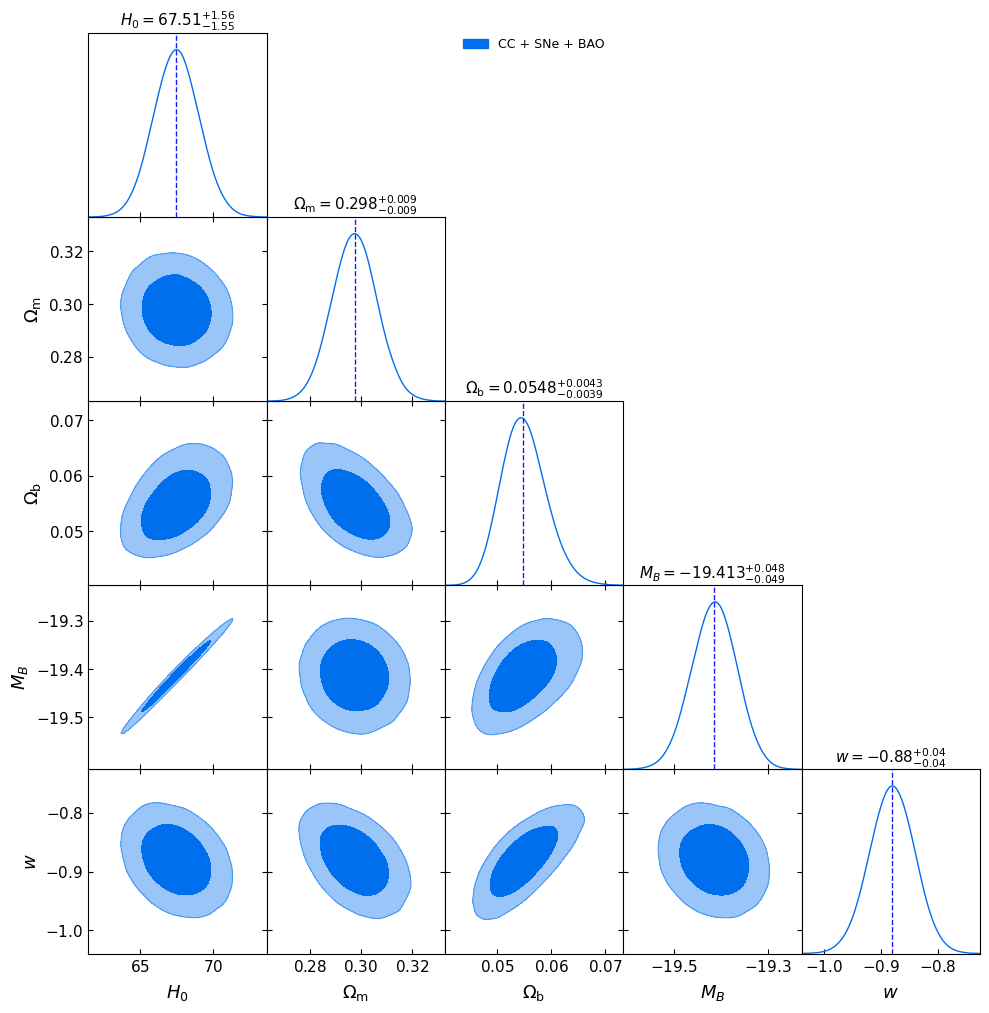

In [10]:
# ====================================================
# Corner plot (GetDist)
# ====================================================

param_names  = ["H0", "Om0", "Ob", "MB", "w"]
param_labels = [r"H_0", r"\Omega_{\rm m}", r"\Omega_{\rm b}", r"M_B", r"w"]

samples_gd = MCSamples(
    samples=flat_samples,
    names=param_names,
    labels=param_labels
)

samples_gd.updateSettings({
    "smooth_scale_1D": 0.25,
    "smooth_scale_2D": 0.25,
    "fine_bins":       1024,
    "fine_bins_2D":    1024,
})

g = plots.get_subplot_plotter()
g.settings.axes_fontsize       = 14
g.settings.lab_fontsize        = 16
g.settings.legend_fontsize     = 12
g.settings.linewidth_contour   = 1.5
g.settings.num_plot_contours   = 2
g.settings.axis_marker_lw      = 1.0
g.settings.figure_legend_frame = False
g.settings.alpha_filled_add    = 0.3

g.triangle_plot(samples_gd, filled=True,
                legend_labels=["CC + SNe + BAO"],
                title_limit=0)

# ---- Fill under curve and add titles from samples ----
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f", "w": ".2f"}

for i, name in enumerate(param_names):
    samples = flat_samples[:, i]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    ep68    = upper68 - median
    em68    = median  - lower68

    ax   = g.subplots[i, i]
    line = ax.get_lines()[0]
    line.set_linewidth(1.0)

    # Median line
    ax.axvline(median, color="blue", lw=1.0, ls="--", alpha=0.9)

    # Add title from samples
    fmt   = fmt_map[name]
    title = f"${param_labels[i]} = {median:{fmt}}^{{+{ep68:{fmt}}}}_{{-{em68:{fmt}}}}$"
    ax.set_title(title, fontsize=11, pad=4)

plt.subplots_adjust(top=0.95)
figname = "Corner_wCDM_cc_sne_bao.png"
plt.savefig(figname, dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# ====================================================
# Marginalized statistics
# ====================================================

param_names_indices = [("H0", 0), ("Om0", 1), ("Ob", 2), ("MB", 3), ("w", 4)]
fmt_map = {"H0": ".2f", "Om0": ".3f", "Ob": ".4f", "MB": ".3f", "w": ".2f"}

print("\n" + "="*60)
print(f"{'Final Inference Results (wCDM model | CC + SNe + BAO data)':^60}")
print("="*60)

for name, idx in param_names_indices:
    samples = flat_samples[:, idx]
    median  = np.percentile(samples, 50)
    lower68 = np.percentile(samples, 16)
    upper68 = np.percentile(samples, 84)
    lower95 = np.percentile(samples, 2.5)
    upper95 = np.percentile(samples, 97.5)
    ep68    = upper68 - median
    em68    = median  - lower68
    ep95    = upper95 - median
    em95    = median  - lower95
    fmt     = fmt_map[name]
    print(f"\n  {name}:")
    print(f"    {median:{fmt}} +{ep68:{fmt}} -{em68:{fmt}}  (68% CL)")
    print(f"    {median:{fmt}} +{ep95:{fmt}} -{em95:{fmt}}  (95% CL)")

print("\n" + "="*60)


 Final Inference Results (wCDM model | CC + SNe + BAO data) 

  H0:
    67.51 +1.56 -1.55  (68% CL)
    67.51 +3.08 -3.03  (95% CL)

  Om0:
    0.298 +0.009 -0.009  (68% CL)
    0.298 +0.018 -0.017  (95% CL)

  Ob:
    0.0548 +0.0043 -0.0039  (68% CL)
    0.0548 +0.0090 -0.0074  (95% CL)

  MB:
    -19.413 +0.048 -0.049  (68% CL)
    -19.413 +0.094 -0.097  (95% CL)

  w:
    -0.88 +0.04 -0.04  (68% CL)
    -0.88 +0.08 -0.08  (95% CL)



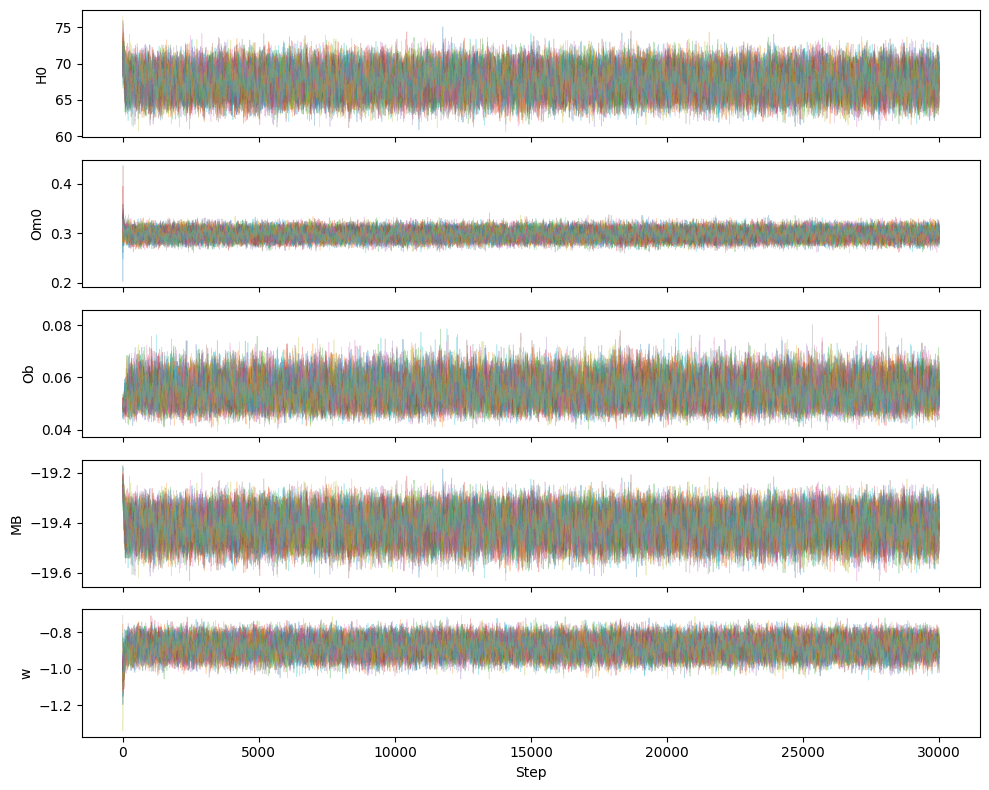

In [12]:
# ====================================================
# Walker chains
# ====================================================

chain_plot = sampler.get_chain().copy()

fig, axes = plt.subplots(5, figsize=(10, 8), sharex=True)
for i, label in enumerate(["H0", "Om0", "Ob", "MB", "w"]):
    axes[i].plot(chain_plot[:, :, i], alpha=0.3, lw=0.5)
    axes[i].set_ylabel(label)
axes[-1].set_xlabel("Step")

plt.tight_layout()
plt.show()

In [13]:
# ========================================================
# Derived Parameter: Sound Horizon rd
# ========================================================

def compute_rd(H0, Om0, Ob):
    h2   = (H0 / 100.0)**2
    Obh2 = Ob * h2
    Omh2 = Om0 * h2
    rd   = 147.05 * ((Obh2 / 0.02236)**-0.13) \
                  * ((Omh2 / 0.1432)**-0.23)  \
                  * ((Neff  / 3.04)**-0.1)
    return rd

# Compute rd for entire posterior
# flat_samples columns: [H0, Om0, Ob, MB, "w", sigma_host, exp_mu]
rd_chain = np.array([
    compute_rd(s[0], s[1], s[2]) for s in flat_samples
])

mean_rd  = np.mean(rd_chain)
std_rd   = np.std(rd_chain)
lower_95 = np.percentile(rd_chain, 2.5)
upper_95 = np.percentile(rd_chain, 97.5)

print("\n" + "="*60)
print(f"{'DERIVED SOUND HORIZON':^60}")
print("="*60)
print(f"  r_d = {mean_rd:.3f} ± {std_rd:.3f} Mpc (68% CL)")
print(f"  95% CL : [{lower_95:.3f}, {upper_95:.3f}] Mpc")
print("="*60)


                   DERIVED SOUND HORIZON                    
  r_d = 146.820 ± 3.198 Mpc (68% CL)
  95% CL : [140.734, 153.236] Mpc
